# Exploratory Data Analysis — Tennis Match Prediction

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

years = range(2019, 2026)
dataframes = []

for year in years:
    df_year = pd.read_excel(f"data/{year}.xlsx")
    df_year["Year"] = year
    dataframes.append(df_year)

df_raw = pd.concat(dataframes, ignore_index=True)
print(f"Total shape: {df_raw.shape}")
print(f"Years present: {df_raw['Year'].unique()}")

Total shape: (17048, 39)
Years present: [2019 2020 2021 2022 2023 2024 2025]


## 1. Basic Inspection

In [13]:
df_raw.head(10)

,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,...,B365L,PSW,PSL,MaxW,MaxL,AvgW,AvgL,Year,BFEW,BFEL
0,1,Brisbane,Brisbane International,2018-12-31,ATP250,Outdoor,Hard,1st Round,3.0,Dimitrov G.,...,3.00,1.36,3.37,1.42,3.60,1.35,3.18,2019,NaN,NaN
1,1,Brisbane,Brisbane International,2018-12-31,ATP250,Outdoor,Hard,1st Round,3.0,Raonic M.,...,4.50,1.23,4.68,1.27,4.84,1.22,4.26,2019,NaN,NaN
2,1,Brisbane,Brisbane International,2018-12-31,ATP250,Outdoor,Hard,1st Round,3.0,Kecmanovic M.,...,2.25,1.67,2.32,1.71,2.40,1.63,2.28,2019,NaN,NaN
3,1,Brisbane,Brisbane International,2018-12-31,ATP250,Outdoor,Hard,1st Round,3.0,Millman J.,...,2.75,1.41,3.13,1.45,3.20,1.40,2.95,2019,NaN,NaN
4,1,Brisbane,Brisbane International,2018-12-31,ATP250,Outdoor,Hard,1st Round,3.0,Uchiyama Y.,...,1.44,2.73,1.51,3.26,1.53,2.69,1.47,2019,NaN,NaN
5,1,Brisbane,Brisbane International,2019-01-01,ATP250,Outdoor,Hard,1st Round,3.0,Kudla D.,...,1.44,2.80,1.49,2.85,1.55,2.70,1.47,2019,NaN,NaN
6,1,Brisbane,Brisbane International,2019-01-01,ATP250,Outdoor,Hard,1st Round,3.0,Chardy J.,...,1.66,2.23,1.72,2.26,1.74,2.19,1.68,2019,NaN,NaN
7,1,Brisbane,Brisbane International,2019-01-01,ATP250,Outdoor,Hard,1st Round,3.0,Murray A.,...,3.50,1.38,3.29,1.39,3.60,1.34,3.26,2019,NaN,NaN
8,1,Brisbane,Brisbane International,2019-01-01,ATP250,Outdoor,Hard,1st Round,3.0,Kyrgios N.,...,2.75,1.47,2.87,1.50,3.16,1.44,2.80,2019,NaN,NaN
9,1,Brisbane,Brisbane International,2019-01-01,ATP250,Outdoor,Hard,1st Round,3.0,Tsonga J.W.,...,1.57,2.27,1.70,2.42,1.71,2.27,1.64,2019,NaN,NaN


In [14]:
df_raw.tail(10)

,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,...,B365L,PSW,PSL,MaxW,MaxL,AvgW,AvgL,Year,BFEW,BFEL
17038,60,Turin,Masters Cup,2025-11-11,Masters Cup,Indoor,Hard,Round Robin,3.0,Musetti L.,...,1.36,3.25,1.40,3.30,1.38,3.13,1.36,2025,3.35,1.42
17039,60,Turin,Masters Cup,2025-11-12,Masters Cup,Indoor,Hard,Round Robin,3.0,Auger-Aliassime F.,...,1.67,2.20,1.76,2.40,1.74,2.18,1.68,2025,2.28,1.76
17040,60,Turin,Masters Cup,2025-11-12,Masters Cup,Indoor,Hard,Round Robin,3.0,Sinner J.,...,7.00,1.13,7.21,1.14,7.50,1.11,6.48,2025,1.14,7.60
17041,60,Turin,Masters Cup,2025-11-13,Masters Cup,Indoor,Hard,Round Robin,3.0,De Minaur A.,...,1.36,3.27,1.39,3.30,1.40,3.09,1.36,2025,3.40,1.40
17042,60,Turin,Masters Cup,2025-11-13,Masters Cup,Indoor,Hard,Round Robin,3.0,Alcaraz C.,...,6.00,1.14,6.88,1.14,7.00,1.13,6.05,2025,1.16,7.00
17043,60,Turin,Masters Cup,2025-11-14,Masters Cup,Indoor,Hard,Round Robin,3.0,Sinner J.,...,10.00,1.10,8.53,1.07,11.00,1.06,9.41,2025,1.08,13.00
17044,60,Turin,Masters Cup,2025-11-14,Masters Cup,Indoor,Hard,Round Robin,3.0,Auger-Aliassime F.,...,4.50,1.21,5.06,1.22,5.30,1.19,4.80,2025,1.22,5.30
17045,60,Turin,Masters Cup,2025-11-15,Masters Cup,Indoor,Hard,Semifinals,3.0,Sinner J.,...,10.00,1.10,8.53,1.07,11.00,1.06,9.44,2025,1.08,13.00
17046,60,Turin,Masters Cup,2025-11-15,Masters Cup,Indoor,Hard,Semifinals,3.0,Alcaraz C.,...,4.50,1.21,5.06,1.22,5.30,1.19,4.75,2025,1.22,5.30
17047,60,Turin,Masters Cup,2025-11-16,Masters Cup,Indoor,Hard,The Final,3.0,Sinner J.,...,2.63,1.50,2.80,1.56,2.80,1.49,2.61,2025,1.52,2.88


## 2. Comment Column 

Comment
Completed       16463
Retired           461
Walkover          116
Awarded             5
Sched               1
Disqualified        1
Rrtired             1
Name: count, dtype: int64


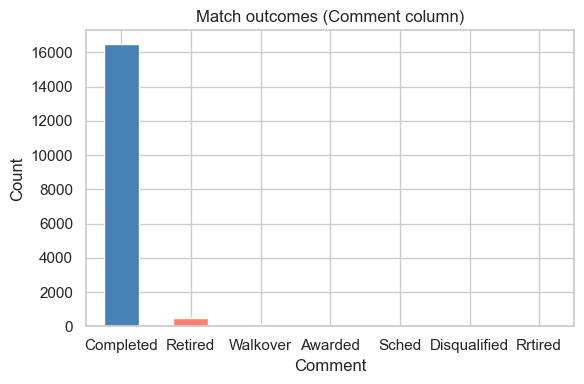

In [15]:
comment_counts = df_raw["Comment"].value_counts()
print(comment_counts)

fig, ax = plt.subplots(figsize=(6, 4))
comment_counts.plot(kind="bar", ax=ax, color=["steelblue", "salmon", "lightgray"])
ax.set_title("Match outcomes (Comment column)")
ax.set_xlabel("Comment")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

df_completed = df_raw[df_raw["Comment"] == "Completed"].copy()

## 3. Missing Values Analysis

         Missing  Missing %
BFEL       15844      96.24
BFEW       15844      96.24
W5         15781      95.86
L5         15781      95.86
W4         14672      89.12
L4         14672      89.12
W3          8352      50.73
L3          8352      50.73
PSW          163       0.99
PSL          163       0.99
B365L         67       0.41
B365W         67       0.41
LRank         38       0.23
LPts          38       0.23
Best of       15       0.09
MaxW          12       0.07
MaxL          12       0.07
AvgW          12       0.07
AvgL          12       0.07
WRank          7       0.04
WPts           6       0.04
L2             1       0.01


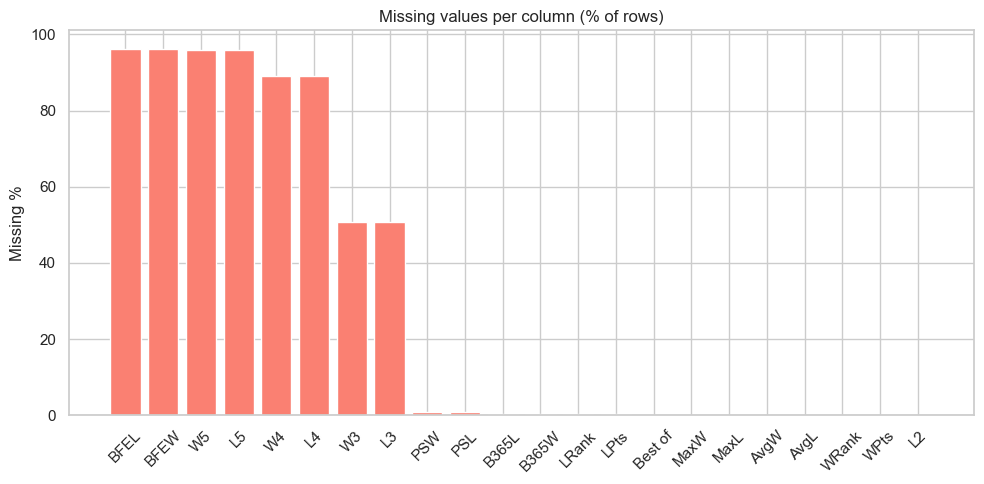

In [16]:
missing = df_completed.isnull().sum()
missing_pct = (missing / len(df_completed) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Missing %": missing_pct}).query("Missing > 0").sort_values("Missing %", ascending=False)
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(missing_df.index, missing_df["Missing %"], color="salmon")
ax.set_title("Missing values per column (% of rows)")
ax.set_ylabel("Missing %")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 4. Categorical Feature Distributions

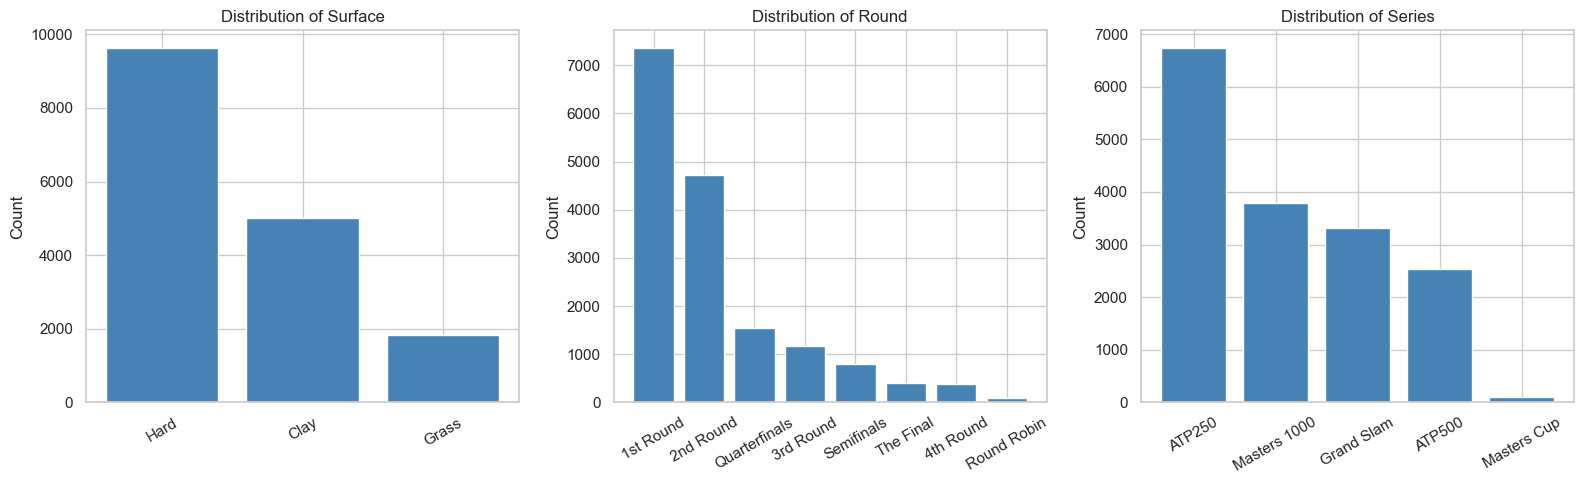

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["Surface", "Round", "Series"]):
    counts = df_completed[col].value_counts()
    ax.bar(counts.index, counts.values, color="steelblue")
    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 5. Court Distribution

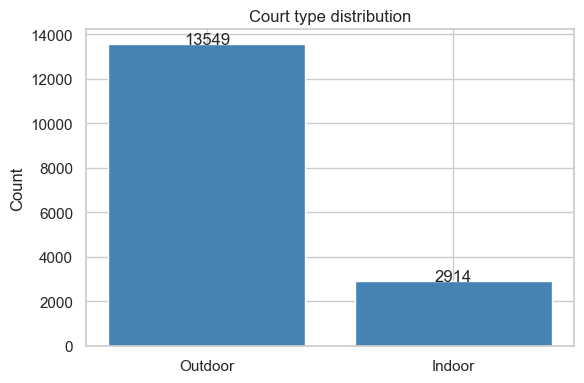

Court distribution:
Court
Outdoor    13549
Indoor      2914
Name: count, dtype: int64


In [18]:
counts = df_completed["Court"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color="steelblue")
ax.set_title("Court type distribution")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
plt.show()

print("Court distribution:")
print(counts)

## 6. Best of Distribution

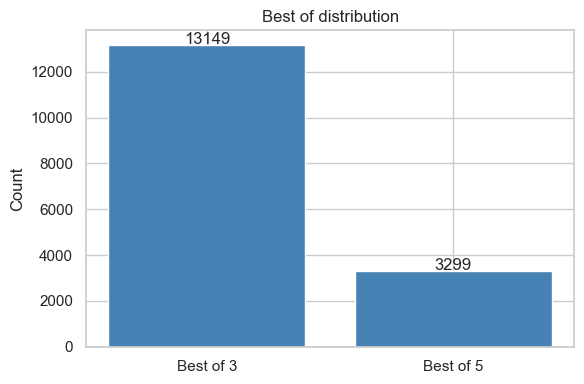

Best of distribution:
Best of
3.0    13149
5.0     3299
Name: count, dtype: int64


In [19]:
counts_bo = df_completed["Best of"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Best of 3", "Best of 5"], counts_bo.values, color="steelblue")
ax.set_title("Best of distribution")
ax.set_ylabel("Count")
for i, v in enumerate(counts_bo.values):
    ax.text(i, v + 50, str(v), ha="center")
plt.tight_layout()
plt.show()

print("Best of distribution:")
print(counts_bo)

## 7. Matches per Season

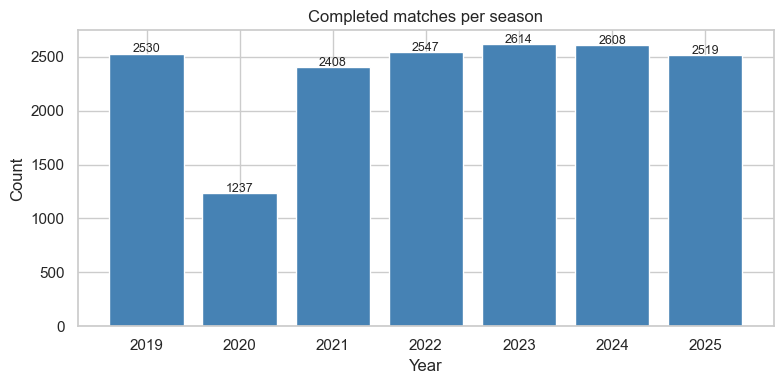

Year
2019    2530
2020    1237
2021    2408
2022    2547
2023    2614
2024    2608
2025    2519
Name: count, dtype: int64


In [20]:
matches_per_year = df_completed["Year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(matches_per_year.index, matches_per_year.values, color="steelblue")
ax.set_title("Completed matches per season")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
for x, v in zip(matches_per_year.index, matches_per_year.values):
    ax.text(x, v + 10, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(matches_per_year)

## 8. Bookmaker Odds Distribution

=== AvgW (odds winner) ===
count    16451.000
mean         1.861
std          1.567
min          1.000
25%          1.300
50%          1.570
75%          2.110
max        161.000
Name: AvgW, dtype: float64
Skewness: 64.614
Mean: 1.861
Median: 1.570

=== AvgL (odds loser) ===
count    16451.000
mean         3.243
std          2.814
min          1.010
25%          1.720
50%          2.400
75%          3.520
max         34.680
Name: AvgL, dtype: float64
Skewness: 3.708
Mean: 3.243
Median: 2.400



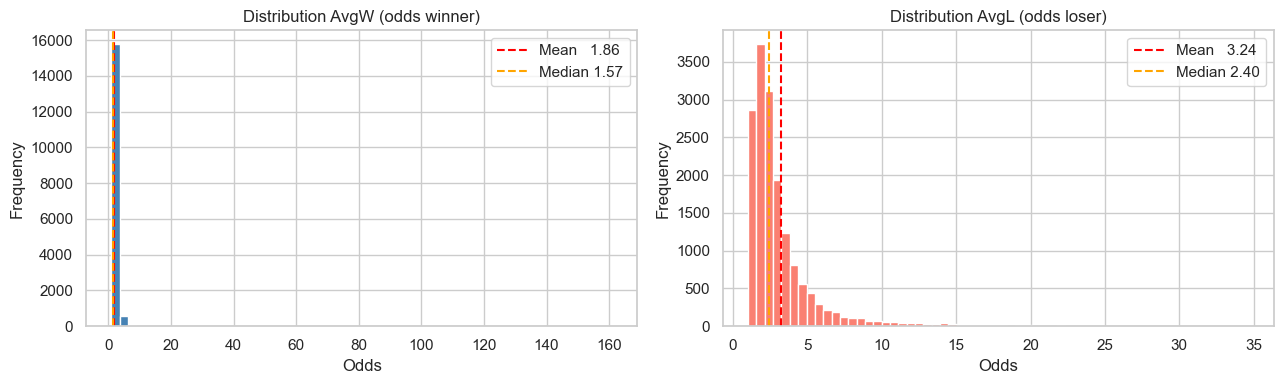

In [21]:
for col, color, label in [("AvgW", "steelblue", "winner"), ("AvgL", "salmon", "loser")]:
    s = df_completed[col].dropna()
    print(f"=== {col} (odds {label}) ===")
    print(s.describe().round(3))
    print(f"Skewness: {s.skew():.3f}")
    print(f"Mean: {s.mean():.3f}")
    print(f"Median: {s.median():.3f}")
    print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, color, label in [
    (axes[0], "AvgW", "steelblue", "winner"),
    (axes[1], "AvgL", "salmon",    "loser"),
]:
    s = df_completed[col].dropna()
    ax.hist(s, bins=60, color=color, edgecolor="white")
    ax.axvline(s.mean(),   color="red",    linestyle="--", linewidth=1.5, label=f"Mean   {s.mean():.2f}")
    ax.axvline(s.median(), color="orange", linestyle="--", linewidth=1.5, label=f"Median {s.median():.2f}")
    ax.set_title(f"Distribution {col} (odds {label})")
    ax.set_xlabel("Odds")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Correlation Matrix of Numerical Features

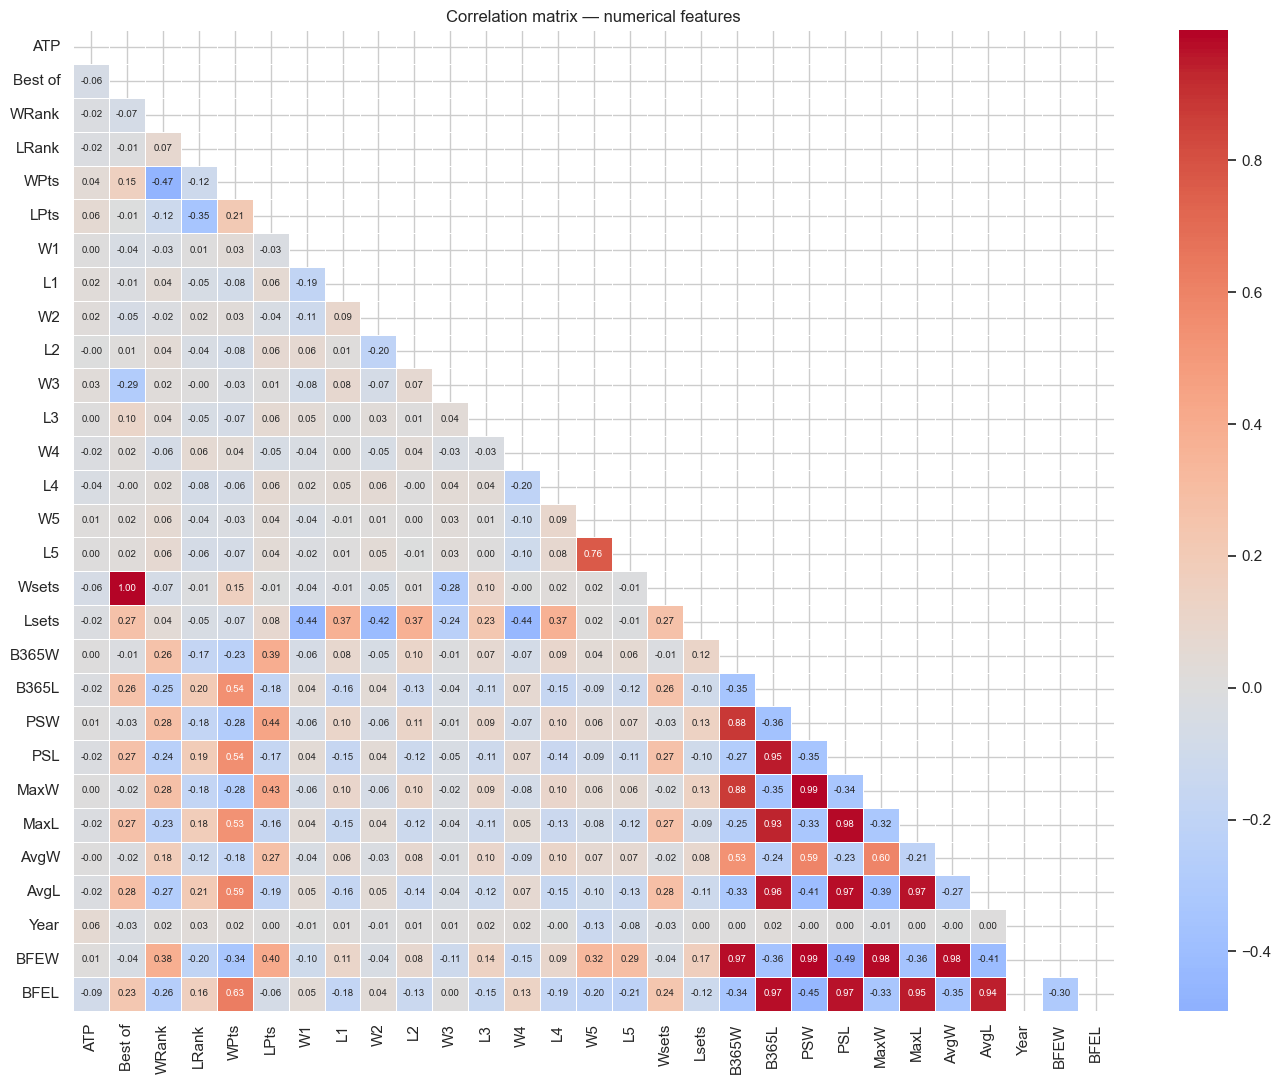

In [22]:
num_cols = df_completed.select_dtypes(include=[np.number]).columns.tolist()
corr = df_completed[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.4,
    ax=ax, annot_kws={"size": 7},
)
ax.set_title("Correlation matrix — numerical features")
plt.tight_layout()
plt.show()